## Buy Box Drivers Descriptive  

### What FACTORS are associated with winning the Buy Box?  
### NOT what causes it  

In [1]:
import sys  
print(sys.executable)

/Users/scottbelarmino/ds_decision_science_exp_repo/project_3_amazon_buy_box_marketplace/.venv/bin/python


In [2]:
import pandas as pd 
import numpy as np  
from pathlib import Path
import matplotlib.pyplot as plt 
import statsmodels.api as sm
import seaborn as sns 
import os 

#PROJECT_ROOT = Path.cwd().resolve()
#print("Project root:", PROJECT_ROOT)

In [3]:
# load data into dataframe

df = pd.read_csv("data/synthetic/marketplace_panel.csv")

df.head()

,day,asin,seller_id,seller_rating,fulfillment_type,shipping_days,product_cost,target_price,base_demand,price,...,price_gap_to_lowest,buy_box_probability,buy_box_winner,market_demand_units,units_sold,revenue,amazon_referral_fee,fulfillment_cost,contribution_profit_per_unit,contribution_profit
0,1,A0001,S032,88.5,FBA,2,82.06,120.02,40,113.24,...,0.00,0.6786,0,49,3,339.72,16.99,5.90,8.29,24.87
1,1,A0001,S028,92.1,FBM,5,82.06,120.02,40,113.80,...,0.56,0.0874,1,49,39,4438.20,17.07,6.25,8.42,328.38
2,1,A0001,S018,86.2,FBM,3,82.06,120.02,40,115.80,...,2.56,0.0348,0,49,2,231.60,17.37,5.55,10.82,21.64
3,1,A0001,S021,91.8,FBA,2,82.06,120.02,40,115.87,...,2.63,0.1474,0,49,4,463.48,17.38,5.90,10.53,42.12
4,1,A0001,S012,93.1,FBA,2,82.06,120.02,40,118.65,...,5.41,0.0350,0,49,0,0.00,17.80,5.90,12.89,0.00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74970 entries, 0 to 74969
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   day                           74970 non-null  int64  
 1   asin                          74970 non-null  object 
 2   seller_id                     74970 non-null  object 
 3   seller_rating                 74970 non-null  float64
 4   fulfillment_type              74970 non-null  object 
 5   shipping_days                 74970 non-null  int64  
 6   product_cost                  74970 non-null  float64
 7   target_price                  74970 non-null  float64
 8   base_demand                   74970 non-null  int64  
 9   price                         74970 non-null  float64
 10  num_competitors               74970 non-null  int64  
 11  lowest_price                  74970 non-null  float64
 12  price_rank                    74970 non-null  int64  
 13  p

### Select Independent Features/Levers that Influence the Buy Box decisions  

|Feature|Why?|
|-|-|
|price_gap_to_lowest| captures priceing competitiveness|
|shipping_days| captures delivery speed|
|seller_rating| captures trust/qualit|
|is_fba| captures platform advantage (Prime Eligible and logistics)|  

Price Rank would create a multicolinearity with price_gap_to_lowest variable, we are already capturing the price competitiveness with a stronger signal/feature

In [7]:
df["is_fba"] = (df["fulfillment_type"] == "FBA").astype(int)

features = [
    "price_gap_to_lowest", #captures pricing competitiveness, continous variable
    "shipping_days", #captures delivery speed
    "seller_rating", #captures seller trust/quality
    "is_fba" #captures Prime Eligible
]

X = df[features]
y = df["buy_box_winner"]

X = sm.add_constant(X) #baseline probability (y intercept): "if everything was zero, what's teh starting probability?"

### Builiding a model that answers:
     "What is the probability a seller wins the Buy Box given these features?"

In [6]:
# Logistic Regression  
# You are teaching a model to estimate the probability of winning the Buy Box based on pricing and seller characteristics.

model = sm.Logit(y, X)
results = model.fit()  

print(results.summary())

Optimization terminated successfully.
         Current function value: 0.288599
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:         buy_box_winner   No. Observations:                74970
Model:                          Logit   Df Residuals:                    74965
Method:                           MLE   Df Model:                            4
Date:                Wed, 18 Mar 2026   Pseudo R-squ.:                  0.3879
Time:                        15:23:35   Log-Likelihood:                -21636.
converged:                       True   LL-Null:                       -35349.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -3.6203      0.273    -13.253      0.000      -4.156      -3.085
pr

### Doesn't provide causation, but: 

    - helps translate your intuition into something measurable  
    - how much does price actually matter vs. shipping vs. FBA?  
    - This enables:  
      - causal thinking (notebook 5)  
      - priceing decisions (noterbook 6)

In [25]:
# Converting Logistic Regression (log-odds) Coefficient to Odds Ratio to be more business friendly interpretation  


pg_coef = results.params["price_gap_to_lowest"]
sd_coef = results.params['shipping_days']
sr_coef = results.params['seller_rating']
fba_coef = results.params['is_fba']

coef_results =[pg_coef, sd_coef, sr_coef, fba_coef]
labels = ['price gap', 'shipping days', 'seller rating', 'is fba']


for l, c in zip(labels, coef_results): 
    print(f'{l} coefficient: {c}')

print('-'*100)

for l,c in zip(labels, coef_results):
    print(f'{l} odd ratio: {np.exp(c)}')

print('-'*100)

for l,c in zip(labels, coef_results):
    print(f'{l} probability interpretation: {np.exp(c)-1}')


price gap coefficient: -0.7731817209963835
shipping days coefficient: -0.3436213071038328
seller rating coefficient: 0.04593455844647152
is fba coefficient: 0.5418290365467062
----------------------------------------------------------------------------------------------------
price gap odd ratio: 0.4615422310479001
shipping days odd ratio: 0.7091974452380174
seller rating odd ratio: 1.0470058910228741
is fba odd ratio: 1.7191483735439428
----------------------------------------------------------------------------------------------------
price gap probability interpretation: -0.5384577689521
shipping days probability interpretation: -0.2908025547619826
seller rating probability interpretation: 0.04700589102287411
is fba probability interpretation: 0.7191483735439428


### Feature Interpretation  

|feature|interpretation|
|-|-|
|price gap|Each $1 price increase REDUCES Buy Box Winning odds by ~54%|
|shipping days|Each additional day of shipping REDUCES Buy Box Winning odds by ~29%|
|seller rating|A 1-point increase in rating INCREASES Buy Box Winning odds by 5%|
|is fba| FBA sellers have a 72% HIGHER odds of winnning the Buy Box|


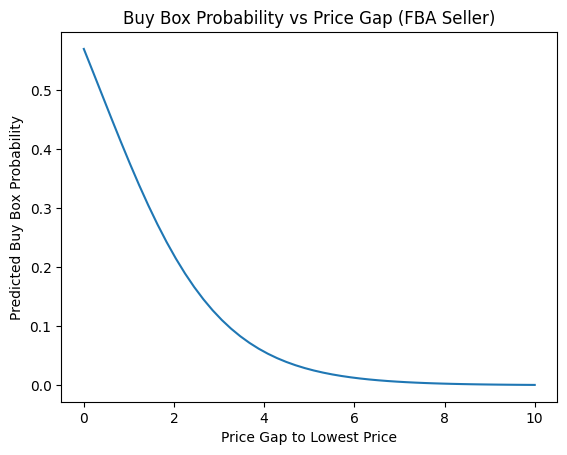

In [10]:

price_range = np.linspace(0, 10, 50)

avg_values = {
    "const": 1,
    "price_gap_to_lowest": price_range,
    "shipping_days": df["shipping_days"].mean(),
    "seller_rating": df["seller_rating"].mean(),
    "is_fba": 1
}

X_plot = pd.DataFrame(avg_values)

pred_probs = results.predict(X_plot)

plt.plot(price_range, pred_probs)
plt.title("Buy Box Probability vs Price Gap (FBA Seller)")
plt.xlabel("Price Gap to Lowest Price")
plt.ylabel("Predicted Buy Box Probability")
plt.show()